In [1]:
import pandas as pd
import sys
sys.path.append('/home/azureuser/cloudfiles/code/Users/manhductranvu/reeval-multi/mirt-official') 
from load_params import load_and_rotate

resmat = pd.read_pickle("../data/resmat.pkl")

theta, a, b = load_and_rotate()

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)

/Users/ronan/Developer/reeval-multi/mirt-official/load_params.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_data = torch.load(model_path, map_location=torch.dev

--- Initial Loaded Data ---
Original theta shape: torch.Size([183, 6])
Original 'a' matrix shape: torch.Size([78712, 6])

--- After Rotation of 'a' ---
Rotated 'a' matrix shape: (78712, 6)

--- After Transformation of 'theta' ---
Transformed theta shape: (183, 6)

--- Final Standardized Z-Scores (from transformed theta) ---
These are the scores you should use for interpretation.
[[ 1.5905465   3.49991235 -2.70676842  0.80146618  0.72562385 -0.62409166]
 [ 1.26710786 -0.50314049  1.10198573 -1.1741239   0.34140497  0.07110775]
 [ 1.86002922  0.60271614  0.90773613  0.07469808 -0.76376825 -1.55688678]
 ...
 [-1.05323766 -0.53844968 -2.76657604  1.42263159  0.66665258  2.97106778]
 [-0.43951293 -0.54343183 -2.60149674  2.23806708  0.32196824  3.12436554]
 [ 0.04734164 -0.47165056 -1.30415358  1.18832103  1.00318341  2.02381296]]


# Math score

In [2]:
import numpy as np
import pandas as pd

def compute_scalar_ability(theta_df, a_df, b_series, math_items, v_unit=None, adjust_difficulty=True):
	"""
	Compute a math-specific ability score from MIRT factors, discriminations, and difficulties.
	
	Args:
		theta_df (pd.DataFrame): Factor scores per test taker (rows = test takers, cols = factors).
		a_df (pd.DataFrame): Discrimination parameters (rows = items, cols = factors).
		b_series (pd.Series): Difficulty parameters (indexed same as a_df rows).
		math_items (list): List of item IDs (subset of a_df rows) that are math items.
		adjust_difficulty (bool): Whether to weight discriminations by difficulty.
	
	Returns:
		pd.Series: Math ability scores for each test taker.
	"""
	if v_unit is None:
		# 1. Extract discrimination vectors for math items
		A_math = a_df.loc[math_items].copy()
		b_math = b_series.loc[math_items]

		# 2. Optionally adjust by difficulty
		if adjust_difficulty:
			weights = 1 / (1 + np.abs(b_math.values))
			A_math = A_math.multiply(weights, axis=0)

		# 3. Compute math direction vector in factor space
		v_unit = A_math.mean(axis=0).values  # vector of length = num_factors
		v_unit = v_unit / np.linalg.norm(v_unit)  # normalize for stability
		print("Mean unit vector: ", v_unit)

	else: 
		print("Used pre-computed math direction vector.", v_unit)

	# 4. Project each test taker's theta onto v_unit
	theta_matrix = theta_df.values  # shape (n_test_takers, n_factors)
	math_scores = theta_matrix.dot(v_unit)

	return pd.Series(math_scores, index=theta_df.index, name="ability")

def compute_projected_vectors(theta_df, a_df, b_series, math_items, v_unit=None, adjust_difficulty=True):
	"""
	Compute math-specific projected ability vectors from MIRT factors, discriminations, and difficulties.
	
	Args:
		theta_df (pd.DataFrame): Factor scores per test taker (rows = test takers, cols = factors).
		a_df (pd.DataFrame): Discrimination parameters (rows = items, cols = factors).
		b_series (pd.Series): Difficulty parameters (indexed same as a_df rows).
		math_items (list): List of item IDs (subset of a_df rows) that are math items.
		adjust_difficulty (bool): Whether to weight discriminations by difficulty.
	
	Returns:
		pd.DataFrame: Projected ability vectors for each test taker (same columns as theta_df).
	"""
	if v_unit is None:
		# 1. Extract discrimination vectors for math items
		A_math = a_df.loc[math_items].copy()
		b_math = b_series.loc[math_items]

		# 2. Optionally adjust by difficulty
		if adjust_difficulty:
			weights = 1 / (1 + np.abs(b_math.values))
			A_math = A_math.multiply(weights, axis=0)

		# 3. Compute math direction vector in factor space
		v_unit = A_math.mean(axis=0).values  # vector of length = num_factors
		v_unit = v_unit / np.linalg.norm(v_unit)  # normalize for stability
		print("Mean unit vector: ", v_unit)
	else:
		print("Used pre-computed math direction vector.", v_unit)

	# 4. Project each test taker's theta vector onto v_unit
	theta_matrix = theta_df.values  # shape (n_test_takers, n_factors)
	scalar_scores = theta_matrix.dot(v_unit)  # shape (n_test_takers,)
	projected_matrix = np.outer(scalar_scores, v_unit)  # shape (n_test_takers, n_factors)

	# 5. Wrap in DataFrame
	projected_df = pd.DataFrame(projected_matrix, 
								index=theta_df.index, 
								columns=theta_df.columns)
	
	return projected_df


In [3]:
models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()
math_items_mask = resmat.columns.get_level_values('scenario').isin(['math'])

math_questions = resmat.columns[math_items_mask].get_level_values('input.text').to_list()

theta_df = pd.DataFrame(theta, index=models)

a_df = pd.DataFrame(a, index=questions)

b_series = pd.Series(b, index=questions)

math_items = math_questions

# Compute math ability
math_scores = compute_scalar_ability(theta_df, a_df, b_series, math_items)
math_vectors = compute_projected_vectors(theta_df, a_df, b_series, math_items)

print("Math scores computed successfully!")
print(f"Math scores range: {math_scores.min():.3f} to {math_scores.max():.3f}")
print(f"\nTop models by math ability:")
with pd.option_context('display.max_rows', 10):
	display(math_scores.sort_values(ascending=False).head(100))
	display(math_vectors.loc[math_scores.sort_values(ascending=False).index])

Mean unit vector:  [-0.53760035 -0.00662218 -0.2944193   0.72835366  0.30550305  0.02069084]
Mean unit vector:  [-0.53760035 -0.00662218 -0.2944193   0.72835366  0.30550305  0.02069084]
Math scores computed successfully!
Math scores range: -2.709 to 2.799

Top models by math ability:


anthropic/claude-3-5-sonnet-20241022    2.798924
anthropic/claude-3-5-sonnet-20240620    2.685637
openai/gpt-4o-2024-05-13                2.641596
openai/gpt-4o-2024-08-06                2.630977
anthropic/claude-3-opus-20240229        2.335345
                                          ...   
writer/palmyra-x                       -0.040833
openai/code-davinci-002                -0.054012
meta/llama-2-70b                       -0.098969
openai/gpt-3.5-turbo-0125              -0.134266
cohere/command-r                       -0.136464
Name: ability, Length: 100, dtype: float64

,0,1,2,3,4,5
anthropic/claude-3-5-sonnet-20241022,-1.504703,-0.018535,-0.824057,2.038607,0.855080,0.057912
anthropic/claude-3-5-sonnet-20240620,-1.443800,-0.017785,-0.790703,1.956094,0.820470,0.055568
openai/gpt-4o-2024-05-13,-1.420123,-0.017493,-0.777737,1.924016,0.807016,0.054657
openai/gpt-4o-2024-08-06,-1.414414,-0.017423,-0.774610,1.916282,0.803771,0.054437
anthropic/claude-3-opus-20240229,-1.255482,-0.015465,-0.687571,1.700957,0.713455,0.048320
...,...,...,...,...,...,...
tiiuae/falcon-7b-instruct,1.303195,0.016053,0.713701,-1.765599,-0.740569,-0.050157
ai21/j1-grande-v2-beta,1.313102,0.016175,0.719126,-1.779021,-0.746198,-0.050538
ai21/j1-large,1.352458,0.016660,0.740680,-1.832343,-0.768564,-0.052053
tiiuae/falcon-7b,1.395136,0.017185,0.764053,-1.890163,-0.792816,-0.053695


In [4]:
conv_benchmark_scores = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['gsm', 'math'])]].mean(axis=1)
convergent_corr = abs(math_scores.corr(conv_benchmark_scores, method='spearman'))
display(convergent_corr)

div_benchmark_scores = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['imdb'])]].mean(axis=1)
divergent_corr = abs(math_scores.corr(div_benchmark_scores, method='spearman'))
display(divergent_corr)

np.float64(0.9249592884792086)

np.float64(0.2017261167304759)

## PCA analysis

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_35534/1987549520.py:93: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


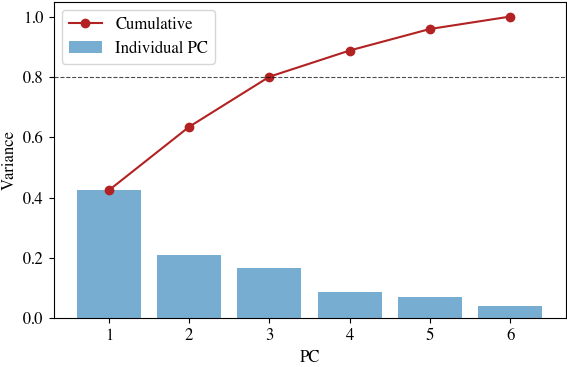

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)


def compute_math_pca(theta_df, a_df, math_items, adjust_difficulty=True,
                     return_mean_vector=False, variance_threshold=0.8, b_series=None):
    """
    Compute math-specific ability dimensions using PCA on discrimination vectors,
    and plot explained variance with threshold.
    
    Args:
        theta_df (pd.DataFrame): Factor scores (models/test-takers x factors)
        a_df (pd.DataFrame): Discrimination parameters (items x factors)
        math_items (list): List of item IDs considered 'pure math'
        adjust_difficulty (bool): Weight items by difficulty if desired
        return_mean_vector (bool): Also compute the mean-based math vector for comparison
        variance_threshold (float): Cumulative explained variance threshold for selecting PCs
        b_series (pd.Series, optional): Item difficulty for weighting
        
    Returns:
        dict:
            'pca_vectors': numpy array (unit vectors of PCs)
            'pca_loadings': pandas DataFrame of factor loadings per PC
            'mean_vector': numpy array (unit vector of mean, optional)
            'scalar_scores': pd.DataFrame of projected scores for each PC
            'explained_variance': array of variance explained per PC
            'num_pcs_above_threshold': int, number of PCs needed to reach cumulative threshold
    """
    # 1. Extract math item discriminations
    A_math = a_df.loc[math_items].copy()
    
    # 2. Optional: adjust by difficulty
    if adjust_difficulty and b_series is not None:
        b_math = b_series.loc[math_items]
        weights = 1 / (1 + np.abs(b_math.values))
        A_math = A_math.multiply(weights, axis=0)

    # 3. Fit PCA on all math items
    pca = PCA()
    pca.fit(A_math.values)
    
    pca_vectors = pca.components_  # shape: n_pcs x n_factors
    # Normalize each PC to unit vector
    pca_vectors = np.array([v / np.linalg.norm(v) for v in pca_vectors])
    
    # 4. Compute factor loadings per PC
    # Loading of PC on original factor = eigenvector * sqrt(eigenvalue)
    pca_loadings = pd.DataFrame(
        pca_vectors.T * np.sqrt(pca.explained_variance_),
        index=A_math.columns,
        columns=[f'PC{i+1}' for i in range(pca_vectors.shape[0])]
    )
    
    item_loadings = pd.DataFrame(
		A_math.values.dot(pca_vectors.T),
		index=A_math.index,
		columns=[f'PC{i+1}' for i in range(pca_vectors.shape[0])]
	)
    
    # 5. Optional: compute mean vector for comparison
    v_mean = None
    if return_mean_vector:
        v_mean = A_math.mean(axis=0).values
        v_mean /= np.linalg.norm(v_mean)
    
    # 6. Project theta onto all PCs
    scalar_scores = pd.DataFrame(theta_df.values.dot(pca_vectors.T),
                                 index=theta_df.index,
                                 columns=[f'PC{i+1}' for i in range(pca_vectors.shape[0])])
    
    # 7. Compute cumulative variance and threshold
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)
    num_pcs_above_threshold = np.searchsorted(cumulative_variance, variance_threshold) + 1
    # 8. Plot explained variance and cumulative variance
    plt.figure(figsize=(6,4))
    plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.6, label='Individual PC')
    plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, color='firebrick', marker='o', label='Cumulative')
    plt.axhline(y=variance_threshold, color='k', linestyle='--', linewidth=0.8, alpha=0.7)
    plt.xlabel('PC')
    plt.ylabel('Variance')
    plt.legend()
    plt.tight_layout()
    plt.savefig('../result/PCA_explained.pdf')
    plt.show()
    
    return {
        'pca_vectors': pca_vectors,
        'pca_loadings': pca_loadings,
        'item_loadings': item_loadings,
        'mean_vector': v_mean,
        'scalar_scores': scalar_scores,
        'explained_variance': explained_variance,
        'num_pcs_above_threshold': num_pcs_above_threshold
    }


models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()
math_items_mask = resmat.columns.get_level_values('scenario').isin(['math', 'gsm'])

math_questions = resmat.columns[math_items_mask].get_level_values('input.text').to_list()

theta_df = pd.DataFrame(theta, index=models)

a_df = pd.DataFrame(a, index=questions)

b_series = pd.Series(b, index=questions)

math_items = math_questions

result = compute_math_pca(theta_df, a_df, math_items, return_mean_vector=True)
scalar_scores = result['scalar_scores']
v_pca = result['pca_vectors']
variance = result['explained_variance']
num_pcs = result['num_pcs_above_threshold']
pca_loadings = result['pca_loadings']
item_loadings = result['item_loadings']

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_35534/2388198812.py:56: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


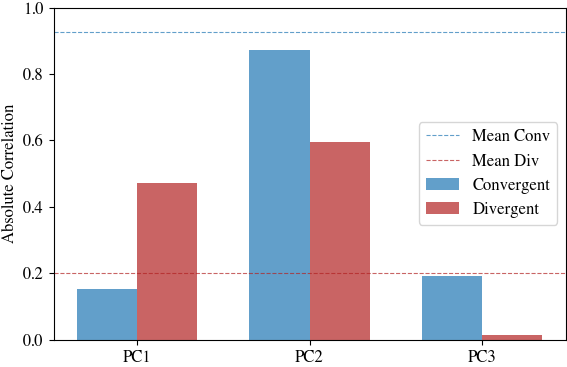

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate correlations for PC1, PC2, PC3
pcs = ['PC1', 'PC2', 'PC3']
conv_corrs = []
div_corrs = []

for pc in pcs:
    conv_corr = abs(scalar_scores[pc].corr(conv_benchmark_scores, method='spearman'))
    div_corr = abs(scalar_scores[pc].corr(div_benchmark_scores, method='spearman'))
    conv_corrs.append(conv_corr)
    div_corrs.append(div_corr)

# Create the two-bar histogram
x = np.arange(len(pcs))  # PC positions
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - width/2, conv_corrs, width, label='Convergent', color='C0', alpha=0.7)
bars2 = ax.bar(x + width/2, div_corrs, width, label='Divergent', color='firebrick', alpha=0.7)


# Add horizontal dashed lines
ax.axhline(y=0.9249592884792086, color='C0', linestyle='--', alpha=0.7, label='Mean Conv', linewidth=0.8)
ax.axhline(y=0.2017261167304759, color='firebrick', linestyle='--', alpha=0.7, label='Mean Div', linewidth=0.8)


# Customize the plot
# ax.set_xlabel('Principal Components')
ax.set_ylabel('Absolute Correlation')
# ax.set_title('PC Correlations with Benchmark Types')
ax.set_xticks(x)
ax.set_xticklabels(pcs)
ax.set_ylim(0, 1)
ax.legend()
# ax.grid(True, alpha=0.3)

# # Add value labels on bars
# for bar in bars1:
#     height = bar.get_height()
#     ax.annotate(f'{height:.3f}',
#                 xy=(bar.get_x() + bar.get_width() / 2, height),
#                 xytext=(0, 3),  # 3 points vertical offset
#                 textcoords="offset points",
#                 ha='center', va='bottom')

# for bar in bars2:
#     height = bar.get_height()
#     ax.annotate(f'{height:.3f}',
#                 xy=(bar.get_x() + bar.get_width() / 2, height),
#                 xytext=(0, 3),  # 3 points vertical offset
#                 textcoords="offset points",
#                 ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../result/pc_correlations_histogram.pdf')
plt.show()

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_35534/67374852.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


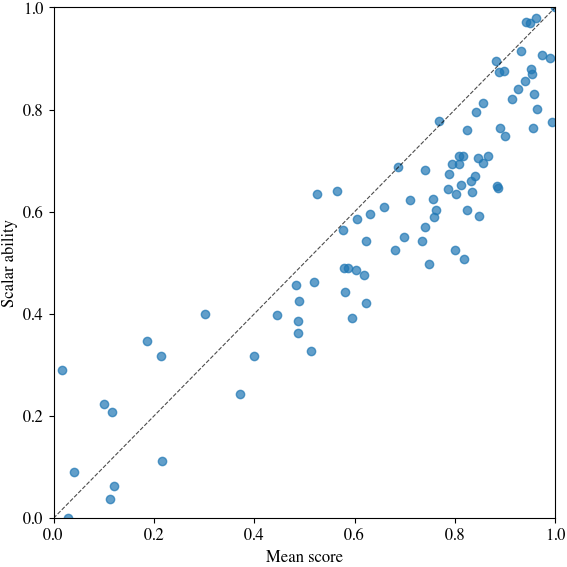

In [10]:
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

math_mean = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['math', 'gsm'])]].mean(axis=1)

math_mean = math_mean[math_mean > 0]

# Scale both series to have same mean and std
scaler = MinMaxScaler()
math_mean_scaled = scaler.fit_transform(math_mean.values.reshape(-1, 1)).flatten()
math_scores_scaled = scaler.fit_transform(math_scores[math_mean.index].values.reshape(-1, 1)).flatten()

math_coordinates = pd.DataFrame({
    'mean': math_mean_scaled,
    'ability': math_scores_scaled
})

math_coordinates = math_coordinates[math_coordinates['mean'] > 0]

# Create scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(math_coordinates['mean'], math_coordinates['ability'], alpha=0.7)
# Add diagonal line
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.7)
plt.ylabel('Scalar ability')
plt.xlabel('Mean score')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('../result/math_ability_vs_mean.pdf')
plt.show()